### Read and pack the velocity/sigma map and parameters

In [1]:
import os
from astropy.table import Table
import preprocess
import configparser
config = configparser.ConfigParser()
config.optionxform = str
kine_data = []
sim_list = os.listdir("muse")
for sim_name in sim_list:
    if os.path.basename(sim_name).startswith("test_"):
        snr_list = os.listdir(os.path.join("muse", sim_name))
        config.read(os.path.join("muse", sim_name, "test.ini")) # read the parameter file
        config_dict = {section: dict(config[section]) for section in config.sections()}
        print(config_dict)
        # choice the parameters to be predicted
        mass = float(config_dict["Potential bulge"]["mass"])
        scaleRadius = float(config_dict["Potential bulge"]["scaleRadius"])
        sersicIndex = float(config_dict["Potential bulge"]["sersicIndex"])
        para_dict = {'mass': mass, 'scaleRadius': scaleRadius, 'sersicIndex': sersicIndex}
        for snr_path in snr_list:
            if os.path.basename(snr_path).startswith("snr="):
                snr = int(snr_path.split("=")[1])
                print(f'pixlelize {sim_name} - {snr_path}')
                data, v_matrix, sigma_matrix = preprocess.read_data(os.path.join("muse", sim_name, snr_path)) # extract the kinematic data as 2D matrix
                kine = para_dict.copy()
                kine.update({"snr": snr, "sim_name": sim_name, "v_matrixs": v_matrix, "sigma_matrixs": sigma_matrix})
                kine_data.append(kine) # store the kinematic data and parameters in a list of dictionaries

kine_data = Table(kine_data)
kine_data.write("kine_data_test.fits", overwrite=True)

{'Potential halo': {'Type': 'Spheroid', 'mass': '100', 'axisRatioZ': '1.0', 'alpha': '1.0', 'gamma': '1', 'beta': '3', 'scaleRadius': '190', 'outerCutoffRadius': '2127'}, 'Potential bulge': {'Type': 'Sersic', 'mass': '2.85', 'scaleRadius': '18', 'sersicIndex': '4', 'axisRatioZ': '0.8'}, 'SelfConsistentModel halo': {'rminSph': '4', 'rmaxSph': '2127', 'sizeRadialSph': '35', 'lmaxAngularSph': '6'}, 'SelfConsistentModel bulge': {'rminSph': '0.03', 'rmaxSph': '108', 'sizeRadialSph': '30', 'lmaxAngularSph': '6'}, 'SelfConsistentModel': {'rminSph': '0.03', 'rmaxSph': '2127', 'sizeRadialSph': '40', 'lmaxAngularSph': '6', 'useActionInterpolation': 'false'}, 'DF bulge': {'type': 'DoublePowerLaw', 'mass': '2.8505278757639205', 'J0': '16.810790920591185', 'slopeIn': '1.8741196038172458', 'slopeOut': '5.511141343404567', 'steepness': '1.155630255650334', 'coefJrIn': '1.143834426096053', 'coefJrOut': '0.35321524770227947', 'Jcutoff': '12.177720676538778', 'cutoffStrength': '19.99999839858346', 'coef

### checking

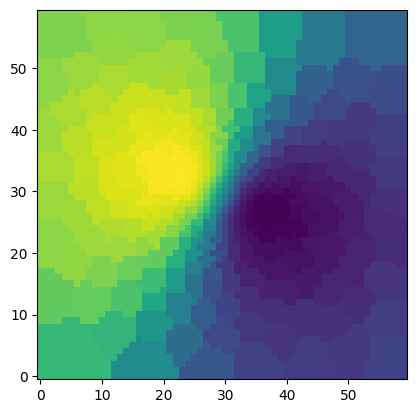

In [2]:
import matplotlib.pyplot as plt
plt.imshow(kine_data['v_matrixs'][1], origin='lower', cmap='viridis')

In [3]:
from astropy.table import Table
import numpy as np
import pprint
kine_data = Table.read("kine_data_test.fits")
norm_config = {
    'mass':         {'mean': np.mean(kine_data['mass']), 'std': np.std(kine_data['mass'])},
    'sersicIndex':  {'mean': np.mean(kine_data['sersicIndex']), 'std': np.std(kine_data['sersicIndex'])},
}
pprint.pprint(norm_config)

{'mass': {'mean': np.float64(12.018418418418419),
          'std': np.float64(8.052955979086326)},
 'sersicIndex': {'mean': np.float64(3.881881881881882),
                 'std': np.float64(0.9256991849640493)}}


### model trainging

In [ ]:
import model
from astropy.table import Table
import numpy as np
pipline = model.Pipeline()
data = Table.read("kine_data_test.fits")
data['maps'] = np.concatenate([np.expand_dims(data['v_matrixs'], axis=1), np.expand_dims(data['sigma_matrixs'], axis=1)], axis=1)
data['paras'] = np.concatenate([np.expand_dims(data['mass'], axis=1), np.expand_dims(data['sersicIndex'], axis=1)], axis=1)
train_data, test_data = data[0:-200], data[-200:]
pipline.cfg['epochs'] = 100
pipline.load_data(train_data)
pipline.Init()
pipline.train_loop()

Using device: cuda
Maps shape= torch.Size([4995, 2, 60, 60]) torch.Size([4995, 2])
Paras type= torch.float32 torch.float32
Training set size: 32 Validation set size: 8


c:\Users\q9775\miniconda3\envs\pytorch-gpu-test\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Validation: 100%|██████████| 8/8 [00:00<00:00, 280.53it/s]
c:\Users\q9775\miniconda3\envs\pytorch-gpu-test\lib\site-packages\torch\optim\lr_scheduler.py:538: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)
d:\OneDrive\桌面\velocity_dis\model.py:122: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.history = pd.concat([self.history, pd.DataFrame([info])], ignore_index=True)


Epoch [1/100], Train Loss: 0.8882, Valid Loss: 0.8298
save the best checkpoint of  models\test_CNN
learning rate [0.001]


Validation: 100%|██████████| 8/8 [00:00<00:00, 257.64it/s]


Epoch [2/100], Train Loss: 0.8070, Valid Loss: 0.8170
save the best checkpoint of  models\test_CNN
learning rate [0.001]


...

Epoch [98/100], Train Loss: 0.2291, Valid Loss: 0.2843
learning rate [1.953125e-06]


Validation: 100%|██████████| 8/8 [00:00<00:00, 268.42it/s]


Epoch [99/100], Train Loss: 0.2291, Valid Loss: 0.2842
learning rate [1.953125e-06]


Validation: 100%|██████████| 8/8 [00:00<00:00, 326.50it/s]

Epoch [100/100], Train Loss: 0.2291, Valid Loss: 0.2842
save the best checkpoint of  models\test_CNN
learning rate [4.8828125e-07]
Training finished.
The best validation loss: 0.28421983337617135
The model is saved in: models\test_CNN


### evaluation

In [4]:
import model
from astropy.table import Table
import numpy as np
data = Table.read("kine_data_test.fits")
data['maps'] = np.concatenate([np.expand_dims(data['v_matrixs'], axis=1), np.expand_dims(data['sigma_matrixs'], axis=1)], axis=1)
data['paras'] = np.concatenate([np.expand_dims(data['mass'], axis=1), np.expand_dims(data['sersicIndex'], axis=1)], axis=1)
train_data, test_data = data[0:-100], data[-100:]
pipline = model.Pipeline()
pipline.Init(cfg_path='models/test_CNN')
pred_data = pipline.predict(test_data)
pred_data.rename_column(pred_data.colnames[0], 'mass')
pred_data.rename_column(pred_data.colnames[1], 'sersicIndex')
pred_data

c:\Users\q9775\miniconda3\envs\pytorch-gpu-test\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Using device: cuda
Maps shape= torch.Size([100, 2, 60, 60]) torch.Size([100, 2])
Paras type= torch.float32 torch.float32


Validation: 100%|██████████| 1/1 [00:00<00:00, 62.33it/s]


mass,sersicIndex
float64,float64
12.76418137550354,4.1688526421785355
13.101836800575256,4.198316216468811
10.93733835220337,3.7417505979537964
12.433090955018997,4.135479539632797
12.014690160751343,4.109664112329483
13.058506965637207,4.693799614906311
5.193694591522217,3.641090303659439
8.077816009521484,3.9718201123178005
7.185789585113525,4.057822220027447


Text(0, 0.5, 'pred sersicIndex')

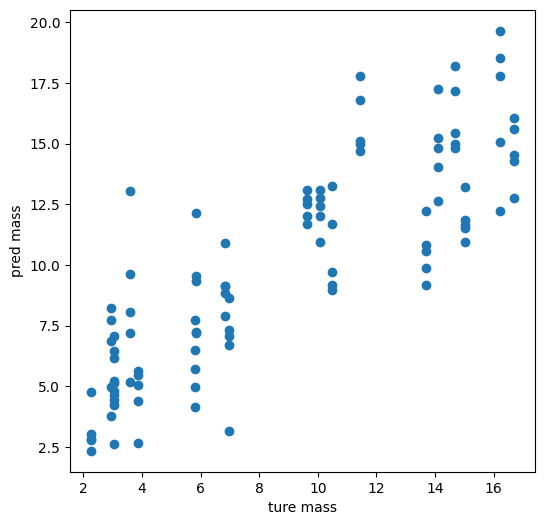

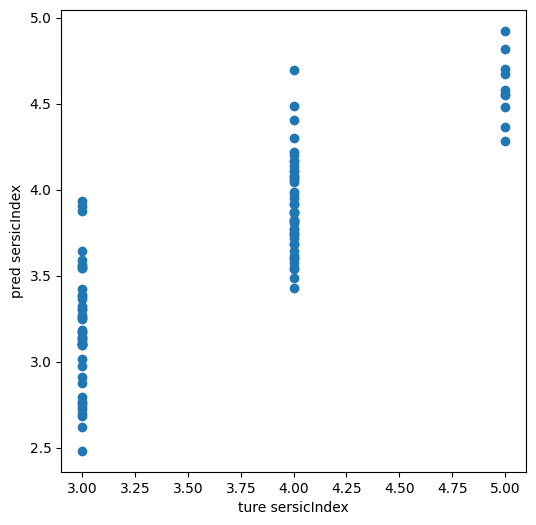

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(test_data['mass'], pred_data['mass'])
plt.xlabel('ture mass')
plt.ylabel('pred mass')

plt.figure(figsize=(6,6))
plt.scatter(test_data['sersicIndex'], pred_data['sersicIndex'])
plt.xlabel('ture sersicIndex')
plt.ylabel('pred sersicIndex')